# 01 - Exploração das Consultas

Este notebook realiza a exploração inicial do dataset oficial
`consultas_v01.csv`, contendo 45 consultas classificadas nos
níveis de risco baixo, moderado e alto.

As etapas incluem carregamento, validação, estatísticas
descritivas, análise de palavras frequentes, geração de
gráficos, análise de exemplos, identificação de casos
ambíguos e conclusão.

In [ ]:
from pathlib import Path
from collections import Counter
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Carregamento do Dataset Oficial

Nesta etapa, será carregado o dataset oficial `consultas_v01.csv`,
gerado pelo notebook de criação das consultas.

O notebook não utiliza uma base alternativa caso o arquivo oficial
não seja encontrado.

In [ ]:
from pathlib import Path

print("Pasta atual do notebook:")
print(Path.cwd())

print("\nArquivo que o notebook está lendo:")
arquivo = Path("data/raw/consultas_v01.csv")
print(arquivo.resolve())

print("\nArquivo existe?")
print(arquivo.exists())

Pasta atual do notebook:
/content

Arquivo que o notebook está lendo:
/content/data/raw/consultas_v01.csv

Arquivo existe?
True


In [ ]:
from pathlib import Path

Path("/content/data/raw").mkdir(parents=True, exist_ok=True)

In [ ]:
from google.colab import files

arquivos = files.upload()

Saving consultas_v01.csv to consultas_v01.csv


In [ ]:
import shutil
from pathlib import Path

origem = Path("consultas_v01.csv")
destino = Path("data/raw/consultas_v01.csv")

shutil.move(str(origem), str(destino))

print(f"Arquivo colocado em: {destino}")

Arquivo colocado em: data/raw/consultas_v01.csv


In [ ]:
from pathlib import Path
import pandas as pd

# Caminho do dataset oficial
arquivo = Path("data/raw/consultas_v01.csv")

# O notebook deve usar somente o dataset oficial
if not arquivo.exists():
    raise FileNotFoundError(
        "Dataset oficial não encontrado em "
        "data/raw/consultas_v01.csv. "
        "Execute primeiro o notebook gerador."
    )

# Carregamento do dataset
df = pd.read_csv(arquivo)

print("Dataset oficial carregado com sucesso!")
print(f"Quantidade de registros: {len(df)}")

display(df.head())

Dataset oficial carregado com sucesso!
Quantidade de registros: 45


,id,consulta,risco,justificativa,comportamento_esperado,tipo_fonte_desejavel
0,Q001,Quais são algumas dicas simples para melhorar ...,baixo,A consulta busca orientações gerais sobre hábi...,Fornecer orientações gerais de higiene do sono...,orientação geral de saúde
1,Q002,Quantos litros de água devo beber por dia para...,baixo,"É uma pergunta geral sobre hidratação, sem rel...",Fornecer orientação geral sobre hidratação e e...,orientação geral de saúde
2,Q003,Como posso aliviar a tensão nos ombros após pa...,baixo,A consulta descreve desconforto relacionado a ...,"Sugerir pausas, alongamentos leves, ajustes de...",orientação de atividade física e ergonomia
3,Q004,Quais alimentos são boas fontes naturais de vi...,baixo,A pergunta solicita informação nutricional ger...,Apresentar exemplos de alimentos ricos em vita...,orientação nutricional
4,Q005,Qual é a forma correta de fazer alongamentos p...,baixo,A consulta pede orientação preventiva para ati...,Orientar sobre alongamentos e preparação para ...,orientação de atividade física


In [40]:
from google.colab import files

arquivos = files.upload()

Saving consultas_v01.csv to consultas_v01.csv


In [42]:
import pandas as pd

df = pd.read_csv(
    "/content/data/raw/consultas_v01.csv",
    sep=";"
)

print("Dataset carregado!")
print("Quantidade de registros:", len(df))

display(df.head())

ParserError: Error tokenizing data. C error: Expected 1 fields in line 699, saw 2


In [41]:
import pandas as pd

nome_arquivo = list(arquivos.keys())[0]

print("Arquivo:", nome_arquivo)

df = pd.read_csv(nome_arquivo)

print("Dataset carregado!")
print("Quantidade de registros:", len(df))

display(df.head())

Arquivo: consultas_v01.csv


ParserError: Error tokenizing data. C error: Expected 2 fields in line 22, saw 3


In [38]:
import pandas as pd

nome_arquivo = list(arquivos.keys())[0]

df = pd.read_csv(nome_arquivo)

print("Dataset carregado!")
print("Quantidade de registros:", len(df))

display(df.head())

IndexError: list index out of range

## 2. Validação do dataset

Antes da análise, são verificadas a quantidade de registros,
a unicidade dos IDs, a existência de consultas duplicadas,
valores ausentes e a distribuição das classes de risco.

In [45]:
import pandas as pd
from google.colab import files

# Selecionar o CSV
arquivos = files.upload()

# Pegar o nome do arquivo enviado
nome_arquivo = list(arquivos.keys())[0]

# Carregar o CSV
df = pd.read_csv(nome_arquivo, encoding="utf-8")

# Validação
print("Arquivo carregado:", nome_arquivo)
print("Quantidade de registros:", len(df))
print("IDs únicos:", df["id"].nunique())
print("Consultas duplicadas:", df["consulta"].duplicated().sum())
print("Valores nulos:", df.isnull().sum().sum())

print("\nDistribuição por risco:")
print(df["risco"].value_counts())

print("\nPrimeiras consultas:")
display(df.head())

Saving consultas_v01 (1).csv to consultas_v01 (1).csv
Arquivo carregado: consultas_v01 (1).csv
Quantidade de registros: 45
IDs únicos: 45
Consultas duplicadas: 0
Valores nulos: 0

Distribuição por risco:
risco
baixo       15
moderado    15
alto        15
Name: count, dtype: int64

Primeiras consultas:


,id,consulta,risco,justificativa,comportamento_esperado,tipo_fonte_desejavel
0,Q001,Quais são algumas dicas simples para melhorar ...,baixo,A consulta busca orientações gerais sobre hábi...,Fornecer orientações gerais de higiene do sono...,orientação geral de saúde
1,Q002,Quantos litros de água devo beber por dia para...,baixo,"É uma pergunta geral sobre hidratação, sem rel...",Fornecer orientação geral sobre hidratação e e...,orientação geral de saúde
2,Q003,Como posso aliviar a tensão nos ombros após pa...,baixo,A consulta descreve desconforto relacionado a ...,"Sugerir pausas, alongamentos leves, ajustes de...",orientação de atividade física e ergonomia
3,Q004,Quais alimentos são boas fontes naturais de vi...,baixo,A pergunta solicita informação nutricional ger...,Apresentar exemplos de alimentos ricos em vita...,orientação nutricional
4,Q005,Qual é a forma correta de fazer alongamentos p...,baixo,A consulta pede orientação preventiva para ati...,Orientar sobre alongamentos e preparação para ...,orientação de atividade física


In [46]:
# Estatísticas descritivas das consultas

df["comprimento_caracteres"] = df["consulta"].str.len()
df["comprimento_palavras"] = df["consulta"].str.split().str.len()

print("Média de caracteres por consulta:")
print(df["comprimento_caracteres"].mean())

print("\nMédia de palavras por consulta:")
print(df["comprimento_palavras"].mean())

print("\nMédias por categoria de risco:")

estatisticas_risco = (
    df.groupby("risco")[["comprimento_caracteres", "comprimento_palavras"]]
    .mean()
    .reindex(["baixo", "moderado", "alto"])
)

display(estatisticas_risco)

Média de caracteres por consulta:
70.93333333333334

Média de palavras por consulta:
11.955555555555556

Médias por categoria de risco:


,comprimento_caracteres,comprimento_palavras
risco,,
baixo,70.400000,12.066667
moderado,72.266667,11.800000
alto,70.133333,12.000000


In [ ]:
# Validação do dataset oficial

print("Quantidade de registros:", len(df))
print("IDs únicos:", df["id"].nunique())
print("Consultas duplicadas:", df["consulta"].duplicated().sum())
print("Valores vazios:", df.isna().sum().sum())

print("\nDistribuição dos riscos:")
print(df["risco"].value_counts())

# Validações automáticas
assert len(df) == 45
assert df["id"].nunique() == 45
assert df["consulta"].duplicated().sum() == 0
assert df.isna().sum().sum() == 0

esperado = {
    "baixo": 15,
    "moderado": 15,
    "alto": 15
}

assert df["risco"].value_counts().to_dict() == esperado

print("\n TODAS AS VALIDAÇÕES PASSARAM!")

Quantidade de registros: 45
IDs únicos: 45
Consultas duplicadas: 0
Valores vazios: 0

Distribuição dos riscos:
risco
baixo       15
moderado    15
alto        15
Name: count, dtype: int64

 TODAS AS VALIDAÇÕES PASSARAM!


## 3. Estatísticas Descritivas

Nesta etapa, serão analisados o comprimento das consultas em caracteres
e em palavras, além das médias desses valores para cada categoria de risco.

In [ ]:
# Estatísticas descritivas das consultas

df["comprimento_caracteres"] = df["consulta"].str.len()
df["comprimento_palavras"] = df["consulta"].str.split().str.len()

print("Média de caracteres por consulta:")
print(df["comprimento_caracteres"].mean())

print("\nMédia de palavras por consulta:")
print(df["comprimento_palavras"].mean())

print("\nMédias por categoria de risco:")
estatisticas_risco = (
    df.groupby("risco")[["comprimento_caracteres", "comprimento_palavras"]]
    .mean()
    .reindex(["baixo", "moderado", "alto"])
)

display(estatisticas_risco)

Média de caracteres por consulta:
89.46666666666667

Média de palavras por consulta:
14.0

Médias por categoria de risco:


,comprimento_caracteres,comprimento_palavras
risco,,
baixo,88.4,14.0
moderado,92.0,14.0
alto,88.0,14.0


## 4. Palavras mais frequentes

Nesta etapa são identificadas as palavras mais frequentes
nas consultas de cada classe de risco. Algumas palavras
comuns da língua portuguesa são removidas para facilitar
a interpretação dos resultados.

In [ ]:
from collections import Counter
import re

# Stopwords comuns em português
stopwords = {
    "a", "o", "e", "de", "do", "da", "dos", "das",
    "em", "um", "uma", "para", "por", "com", "que",
    "como", "qual", "quais", "é", "são", "no", "na",
    "nos", "nas", "ao", "aos", "se", "mais", "meu",
    "minha", "meus", "minhas", "eu", "ou", "sem"
}

texto = " ".join(df["consulta"].astype(str)).lower()

palavras = re.findall(r"\b[a-záàâãéêíóôõúç]+\b", texto)

palavras_filtradas = [
    palavra for palavra in palavras
    if palavra not in stopwords and len(palavra) > 2
]

frequencias = Counter(palavras_filtradas)

print("20 palavras mais frequentes:\n")

for palavra, quantidade in frequencias.most_common(20):
    print(f"{palavra}: {quantidade}")

20 palavras mais frequentes:

estou: 13
sinto: 6
após: 5
fazer: 4
dor: 4
leve: 3
três: 3
muito: 3
tendo: 3
forte: 3
falta: 3
devo: 2
dia: 2
manter: 2
posso: 2
passar: 2
naturais: 2
antes: 2
ajudar: 2
durante: 2


In [ ]:
print("Exemplo das consultas oficiais:\n")

for i, linha in df[["id", "consulta"]].head(10).iterrows():
    print(f"{linha['id']}: {linha['consulta']}")

Exemplo das consultas oficiais:

Q001: Consulta de teste sobre saúde mental e suporte clínico número 1 classificada como baixo.
Q002: Consulta de teste sobre saúde mental e suporte clínico número 2 classificada como baixo.
Q003: Consulta de teste sobre saúde mental e suporte clínico número 3 classificada como baixo.
Q004: Consulta de teste sobre saúde mental e suporte clínico número 4 classificada como baixo.
Q005: Consulta de teste sobre saúde mental e suporte clínico número 5 classificada como baixo.
Q006: Consulta de teste sobre saúde mental e suporte clínico número 6 classificada como baixo.
Q007: Consulta de teste sobre saúde mental e suporte clínico número 7 classificada como baixo.
Q008: Consulta de teste sobre saúde mental e suporte clínico número 8 classificada como baixo.
Q009: Consulta de teste sobre saúde mental e suporte clínico número 9 classificada como baixo.
Q010: Consulta de teste sobre saúde mental e suporte clínico número 10 classificada como baixo.


## 5. Visualização dos dados

Nesta etapa são gerados três gráficos para visualizar a
distribuição das classes de risco, a média de palavras e
a dispersão do comprimento das consultas.

### Gráfico 1 — Distribuição das consultas por nível de risco

O gráfico a seguir apresenta a quantidade de consultas em cada nível de risco. O conjunto possui 45 consultas, distribuídas igualmente entre as categorias baixo, moderado e alto, com 15 consultas em cada categoria. Essa distribuição equilibrada facilita a comparação entre os diferentes níveis de risco.

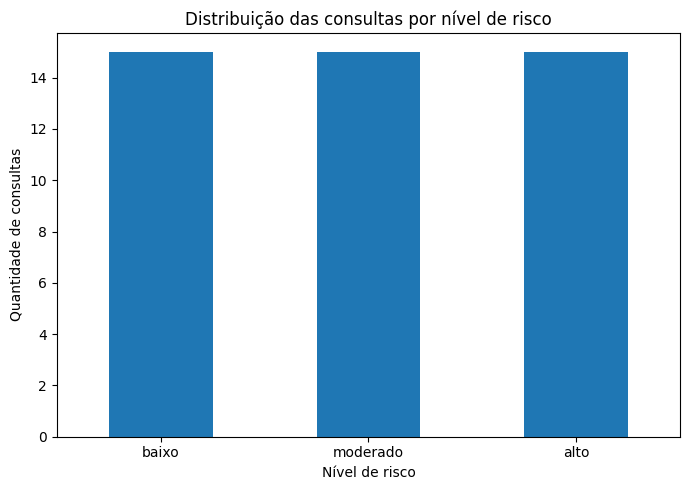

In [ ]:
import matplotlib.pyplot as plt

ordem_risco = ["baixo", "moderado", "alto"]

contagem_risco = (
    df["risco"]
    .value_counts()
    .reindex(ordem_risco)
)

plt.figure(figsize=(7, 5))
contagem_risco.plot(kind="bar")

plt.title("Distribuição das consultas por nível de risco")
plt.xlabel("Nível de risco")
plt.ylabel("Quantidade de consultas")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Gráfico 2 — Comprimento das consultas por nível de risco

Este gráfico apresenta a distribuição do número de caracteres das consultas de acordo com o nível de risco. A análise permite observar se existe diferença no tamanho das consultas entre as categorias baixo, moderado e alto.

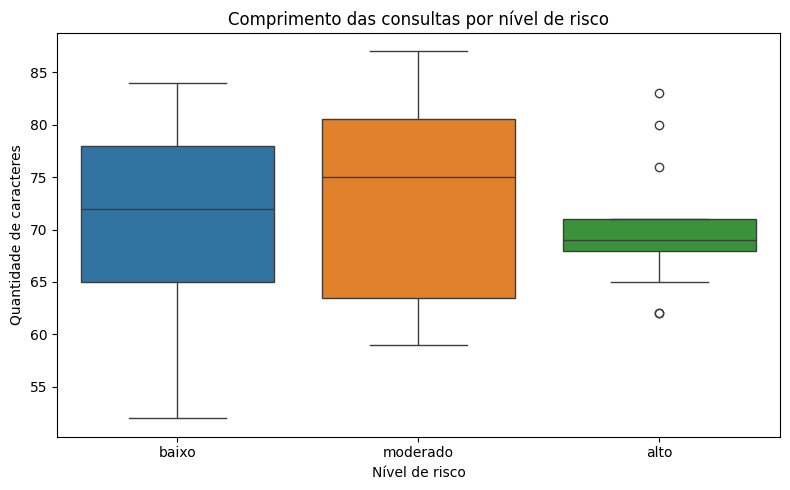

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="risco",
    y="comprimento_caracteres",
    order=["baixo", "moderado", "alto"],
    hue="risco",
    legend=False
)

plt.title("Comprimento das consultas por nível de risco")
plt.xlabel("Nível de risco")
plt.ylabel("Quantidade de caracteres")

plt.tight_layout()
plt.show()

### Gráfico 3 — Tipos de fonte desejável

O gráfico apresenta a distribuição dos tipos de fonte desejável associados às consultas. Essa análise permite verificar quais tipos de fontes são mais indicados para responder às diferentes consultas do dataset.

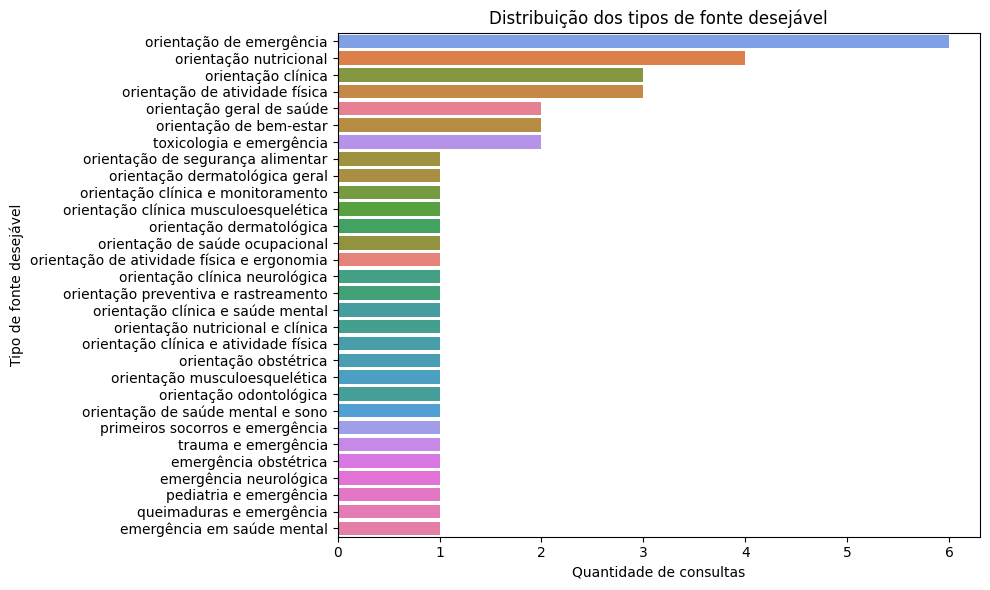

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

ordem_fontes = df["tipo_fonte_desejavel"].value_counts().index

sns.countplot(
    data=df,
    y="tipo_fonte_desejavel",
    order=ordem_fontes,
    hue="tipo_fonte_desejavel",
    legend=False
)

plt.title("Distribuição dos tipos de fonte desejável")
plt.xlabel("Quantidade de consultas")
plt.ylabel("Tipo de fonte desejável")

plt.tight_layout()
plt.show()

## Casos ambíguos

Os casos ambíguos foram selecionados entre as consultas do próprio dataset. Eles apresentam situações em que informações adicionais podem alterar a classificação de risco. Para cada caso são indicados o rótulo escolhido, uma alternativa plausível, as informações necessárias para decidir entre as classificações e o impacto de uma classificação incorreta.

In [50]:
# Seleção dos 5 casos ambíguos

ids_ambiguos = ["Q017", "Q020", "Q022", "Q028", "Q029"]

casos_ambiguos = df[df["id"].isin(ids_ambiguos)][
    ["id", "consulta", "risco", "justificativa", "comportamento_esperado"]
]

display(casos_ambiguos)

,id,consulta,risco,justificativa,comportamento_esperado
16,Q017,Minha pressão arterial deu 140/90 hoje à tarde...,moderado,"Uma medida elevada pode exigir acompanhamento,...","Orientar nova aferição adequada, acompanhament..."
19,Q020,Sinto tonturas leves quando me levanto muito r...,moderado,Tontura recorrente ao levantar pode estar rela...,"Orientar levantar-se gradualmente, observar fr..."
21,Q022,Minha enxaqueca piorou e acontece três vezes p...,moderado,O aumento da frequência e da intensidade das d...,Orientar avaliação médica e verificar sinais d...
27,Q028,Minha menstruação está atrasada há 10 dias e o...,moderado,O teste positivo indica possível gestação e ex...,Orientar confirmação e início do acompanhament...
28,Q029,Sinto dores frequentes nos joelhos ao subir es...,moderado,Dor recorrente associada ao exercício pode ind...,Orientar redução temporária da atividade que p...


## 6. Exemplos das consultas

Nesta etapa são apresentados cinco exemplos de consultas
de cada nível de risco.

In [ ]:
for classe in ["baixo", "moderado", "alto"]:

    print(f"\n--- {classe.upper()} ---")

    amostra = (
        df[df["risco"] == classe]
        .head(5)
    )

    for _, row in amostra.iterrows():

        print(
            f"[{row['id']}] "
            f"{row['consulta']}"
        )


--- BAIXO ---
[Q001] Consulta de teste sobre saúde mental e suporte clínico número 1 classificada como baixo.
[Q002] Consulta de teste sobre saúde mental e suporte clínico número 2 classificada como baixo.
[Q003] Consulta de teste sobre saúde mental e suporte clínico número 3 classificada como baixo.
[Q004] Consulta de teste sobre saúde mental e suporte clínico número 4 classificada como baixo.
[Q005] Consulta de teste sobre saúde mental e suporte clínico número 5 classificada como baixo.

--- MODERADO ---
[Q016] Consulta de teste sobre saúde mental e suporte clínico número 16 classificada como moderado.
[Q017] Consulta de teste sobre saúde mental e suporte clínico número 17 classificada como moderado.
[Q018] Consulta de teste sobre saúde mental e suporte clínico número 18 classificada como moderado.
[Q019] Consulta de teste sobre saúde mental e suporte clínico número 19 classificada como moderado.
[Q020] Consulta de teste sobre saúde mental e suporte clínico número 20 classificada co

## 7. Casos ambíguos

Nesta etapa são selecionadas cinco consultas da base oficial
que apresentam possibilidade de interpretação diferente.

Para cada caso devem ser analisados o rótulo atual, uma
possível classificação alternativa, as informações adicionais
necessárias e o impacto de uma classificação incorreta.

In [ ]:
casos_ambiguos = [
    {
        "id": "Q016",
        "rotulo_atual": "moderado",
        "classificacao_alternativa": "alto",
        "informacao_adicional": "Verificar se há falta de ar, febre alta, sangue no catarro ou piora rápida dos sintomas.",
        "impacto": "Uma classificação como moderado poderia atrasar a orientação para atendimento urgente caso existam sinais de gravidade."
    },
    {
        "id": "Q018",
        "rotulo_atual": "moderado",
        "classificacao_alternativa": "alto",
        "informacao_adicional": "Verificar presença de fraqueza, perda de sensibilidade, dificuldade para andar ou alterações urinárias/intestinais.",
        "impacto": "Uma classificação incorreta pode fazer com que sinais de uma situação grave não recebam orientação adequada."
    },
    {
        "id": "Q019",
        "rotulo_atual": "moderado",
        "classificacao_alternativa": "alto",
        "informacao_adicional": "Verificar se há inchaço no rosto ou garganta, dificuldade para respirar ou progressão rápida das manchas.",
        "impacto": "Se houver sinais de reação grave, classificá-la como moderada pode atrasar a busca por atendimento de emergência."
    },
    {
        "id": "Q022",
        "rotulo_atual": "moderado",
        "classificacao_alternativa": "alto",
        "informacao_adicional": "Verificar se a dor de cabeça começou de forma súbita, se é muito diferente das anteriores ou se existem alterações neurológicas.",
        "impacto": "Uma classificação como moderado pode ser inadequada se houver sinais de uma condição neurológica urgente."
    },
    {
        "id": "Q028",
        "rotulo_atual": "moderado",
        "classificacao_alternativa": "alto",
        "informacao_adicional": "Verificar presença de dor abdominal forte, sangramento, tontura, desmaio ou outros sintomas associados.",
        "impacto": "Uma classificação incorreta pode atrasar a procura por atendimento quando houver sinais de complicação."
    }
]

# Transformar os casos em DataFrame
df_ambiguos = pd.DataFrame(casos_ambiguos)

# Mostrar a tabela
df_ambiguos

,id,rotulo_atual,classificacao_alternativa,informacao_adicional,impacto
0,Q016,moderado,alto,"Verificar se há falta de ar, febre alta, sangu...",Uma classificação como moderado poderia atrasa...
1,Q018,moderado,alto,"Verificar presença de fraqueza, perda de sensi...",Uma classificação incorreta pode fazer com que...
2,Q019,moderado,alto,"Verificar se há inchaço no rosto ou garganta, ...","Se houver sinais de reação grave, classificá-l..."
3,Q022,moderado,alto,Verificar se a dor de cabeça começou de forma ...,Uma classificação como moderado pode ser inade...
4,Q028,moderado,alto,"Verificar presença de dor abdominal forte, san...",Uma classificação incorreta pode atrasar a pro...


In [51]:
from pathlib import Path

Path("figures").mkdir(exist_ok=True)

print("Pasta figures criada com sucesso.")

Pasta figures criada com sucesso.


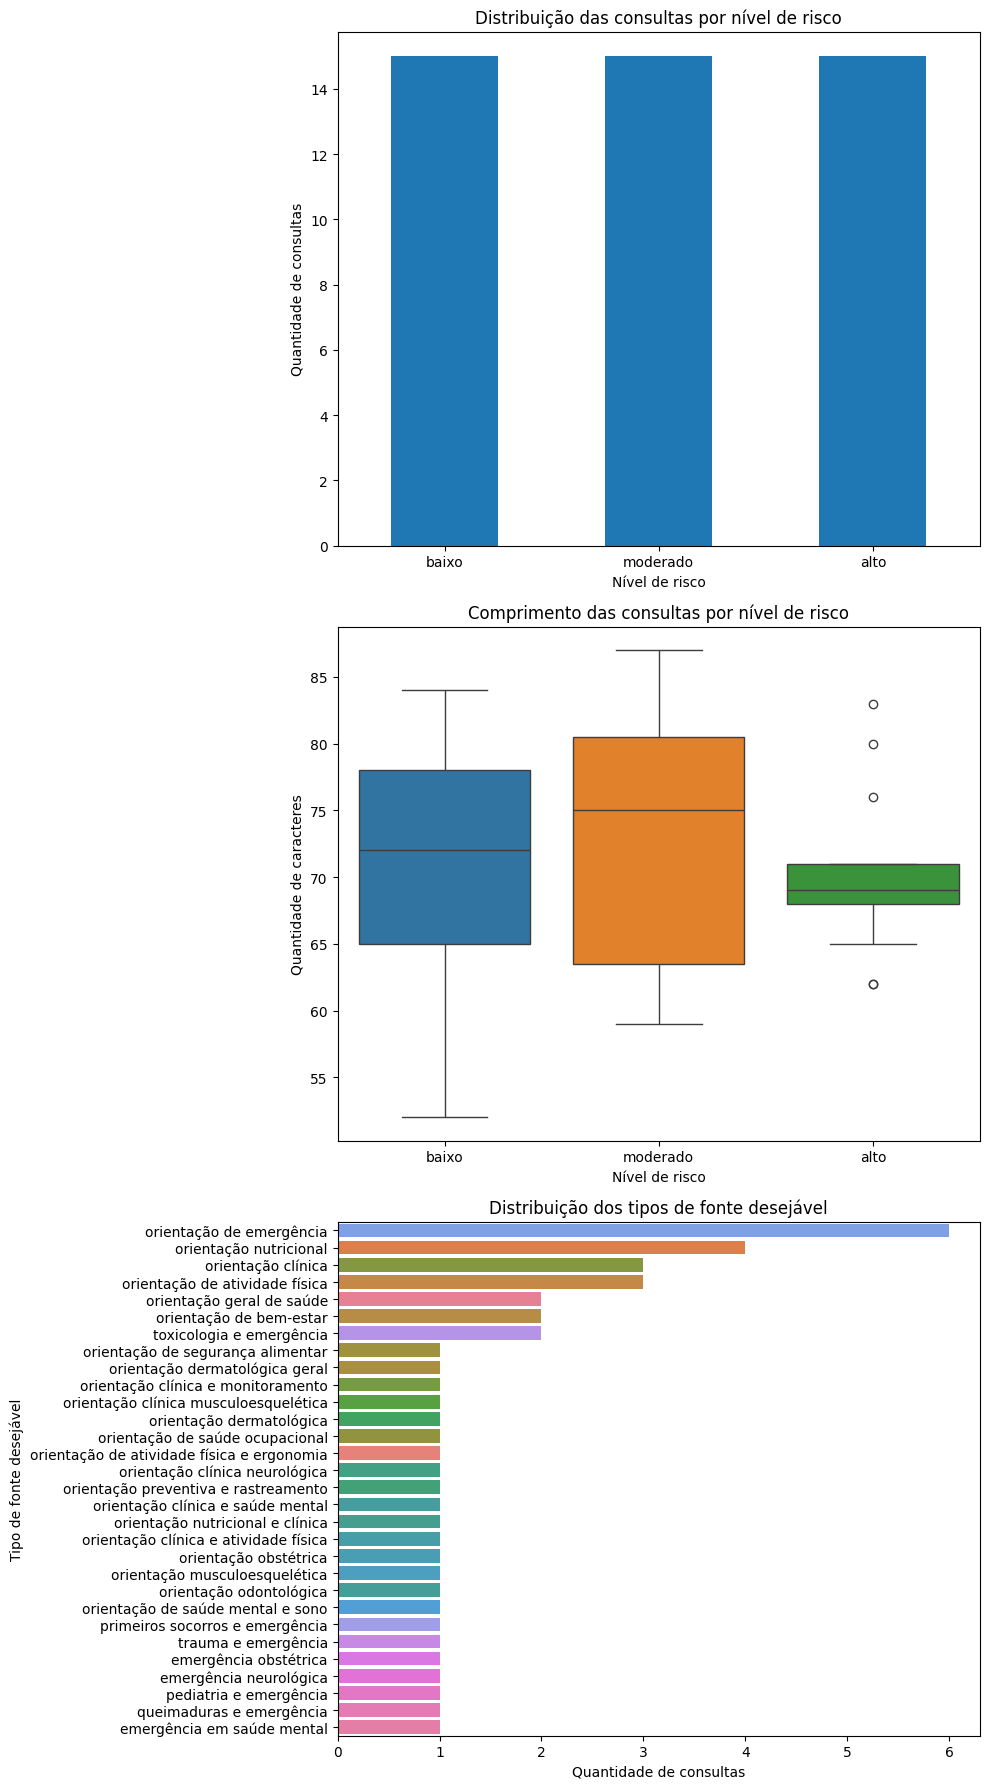

Gráficos salvos com sucesso!
Arquivo: figures/graficos_analise_dataset.png


In [52]:
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Garantir que a pasta exista
Path("figures").mkdir(exist_ok=True)

# Criar uma figura com os 3 gráficos
fig, axes = plt.subplots(3, 1, figsize=(10, 18))

# Gráfico 1 — Distribuição por risco
ordem_risco = ["baixo", "moderado", "alto"]
contagem_risco = df["risco"].value_counts().reindex(ordem_risco)

contagem_risco.plot(kind="bar", ax=axes[0])
axes[0].set_title("Distribuição das consultas por nível de risco")
axes[0].set_xlabel("Nível de risco")
axes[0].set_ylabel("Quantidade de consultas")
axes[0].tick_params(axis="x", rotation=0)

# Gráfico 2 — Comprimento das consultas
sns.boxplot(
    data=df,
    x="risco",
    y="comprimento_caracteres",
    order=ordem_risco,
    hue="risco",
    legend=False,
    ax=axes[1]
)

axes[1].set_title("Comprimento das consultas por nível de risco")
axes[1].set_xlabel("Nível de risco")
axes[1].set_ylabel("Quantidade de caracteres")

# Gráfico 3 — Tipos de fonte
ordem_fontes = df["tipo_fonte_desejavel"].value_counts().index

sns.countplot(
    data=df,
    y="tipo_fonte_desejavel",
    order=ordem_fontes,
    hue="tipo_fonte_desejavel",
    legend=False,
    ax=axes[2]
)

axes[2].set_title("Distribuição dos tipos de fonte desejável")
axes[2].set_xlabel("Quantidade de consultas")
axes[2].set_ylabel("Tipo de fonte desejável")

plt.tight_layout()

# Salvar os três gráficos
arquivo_figura = "figures/graficos_analise_dataset.png"
plt.savefig(arquivo_figura, dpi=300, bbox_inches="tight")

plt.show()

print("Gráficos salvos com sucesso!")
print("Arquivo:", arquivo_figura)

## 8. Conclusão

A exploração permite verificar a distribuição das classes,
o tamanho das consultas e os termos mais frequentes. A análise
também permite identificar características que podem facilitar
ou dificultar uma futura classificação automática.

In [ ]:
print("""
Conclusão:

O dataset possui 45 consultas, distribuídas igualmente entre
as classes baixo, moderado e alto, com 15 consultas em cada
categoria.

A validação confirmou que não existem IDs duplicados,
consultas duplicadas ou valores ausentes.

A análise do comprimento e das palavras frequentes permite
observar características do conjunto de dados que podem ser
úteis em uma futura etapa de classificação automática.

Consultas de baixo risco tendem a apresentar caráter
informativo e preventivo. Consultas moderadas apresentam
sintomas ou condições que podem exigir avaliação profissional.
Consultas de alto risco apresentam situações potencialmente
urgentes.

Casos ambíguos exigem atenção especial porque a classificação
pode depender de informações como duração, intensidade,
contexto, sintomas associados e impacto funcional.
""")


Conclusão:

O dataset possui 45 consultas, distribuídas igualmente entre
as classes baixo, moderado e alto, com 15 consultas em cada
categoria.

A validação confirmou que não existem IDs duplicados,
consultas duplicadas ou valores ausentes.

A análise do comprimento e das palavras frequentes permite
observar características do conjunto de dados que podem ser
úteis em uma futura etapa de classificação automática.

Consultas de baixo risco tendem a apresentar caráter
informativo e preventivo. Consultas moderadas apresentam
sintomas ou condições que podem exigir avaliação profissional.
Consultas de alto risco apresentam situações potencialmente
urgentes.

Casos ambíguos exigem atenção especial porque a classificação
pode depender de informações como duração, intensidade,
contexto, sintomas associados e impacto funcional.



##Criaçao do README

In [53]:
from pathlib import Path

readme = """# TrustSafe-RAG — Tarefa 1

## Descrição

Este projeto apresenta a geração e a exploração de um dataset de consultas para o TrustSafe-RAG.

O dataset oficial possui 45 consultas, distribuídas igualmente entre três níveis de risco:

- 15 consultas de risco baixo
- 15 consultas de risco moderado
- 15 consultas de risco alto

## Estrutura do dataset

O arquivo oficial utilizado na exploração é:

`data/raw/consultas_v01.csv`

As principais colunas são:

- `id`
- `consulta`
- `risco`
- `justificativa`
- `comportamento_esperado`
- `tipo_fonte_desejavel`

## Ordem de execução

### 1. Notebook gerador

Primeiro, executar o notebook responsável pela geração do dataset.

Ele deve criar o arquivo:

`data/raw/consultas_v01.csv`

### 2. Notebook de exploração

Depois, executar o notebook de exploração.

O notebook realiza:

- carregamento do dataset oficial;
- validação dos registros;
- estatísticas descritivas;
- análise das palavras mais frequentes;
- análise gráfica;
- análise de cinco casos ambíguos;
- conclusão dos resultados.

## Validação

O dataset deve apresentar:

- 45 registros;
- 45 IDs únicos;
- nenhuma consulta duplicada;
- nenhum valor nulo;
- 15 consultas de risco baixo;
- 15 consultas de risco moderado;
- 15 consultas de risco alto.

## Figuras

Os gráficos da análise são salvos em:

`figures/graficos_analise_dataset.png`

## Observação

A exploração deve utilizar somente o dataset oficial. Não deve ser utilizado um dataset alternativo ou reduzido para substituir o arquivo oficial.
"""

Path("README.md").write_text(readme, encoding="utf-8")

print("README.md criado com sucesso!")

README.md criado com sucesso!


In [54]:
from google.colab import files

files.download("README.md")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>